In [1]:
from pathlib import Path
import pandas as pd
import torch
import matplotlib.pyplot as plt
import xarray as xr
import yaml
import geopandas as gpd
import numpy as np
import pickle
from neuralhydrology.evaluation.metrics import calculate_all_metrics
from neuralhydrology.evaluation.metrics import calculate_metrics
from neuralhydrology.evaluation.metrics import missed_peaks
import neuralhydrology

In [2]:
# ------------------- Paths -------------------
RUN_DIR = Path("../runs") #Uruguay
# RUN_DIR = Path("../extending_caravan/runs") #USA

# Ensemble metrics

In [3]:
# URUGUAY

run_pattern = "precip_prcp_mm_day_seed_*"
# run_pattern = "precip_prcp_chirps_mm_day_seed_*"
# run_pattern = "precip_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_seed_*" 
# run_pattern = "precip_prcp_mm_day_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_chirps_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*" 
# run_pattern = "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*" 
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*" 

matched_paths = sorted(RUN_DIR.glob(f"{run_pattern}/validation/model_epoch030/validation_results.p"))
print(f"Found {len(matched_paths)} runs: {[p.parts[-4] for p in matched_paths]}")

Found 8 runs: ['precip_prcp_mm_day_seed_111_2202_184533', 'precip_prcp_mm_day_seed_222_2202_185112', 'precip_prcp_mm_day_seed_333_2202_185649', 'precip_prcp_mm_day_seed_444_2202_190226', 'precip_prcp_mm_day_seed_555_2302_064058', 'precip_prcp_mm_day_seed_666_2302_064647', 'precip_prcp_mm_day_seed_777_2302_065235', 'precip_prcp_mm_day_seed_888_2302_065823']


In [4]:
# USA

# run_pattern = "154_camels_30_epochs_seq_270_hidden_256_dropout_04_fb_05_seed111_1103_063301" # CAMELS
# run_pattern = "caravan_154_precip_seq_270_30_epochs_hidden_256_dropout_04_fb_05_seed111_0103_211409" # CARAVAN
# run_pattern = "precip_chirps_precipitation_0503_093821" # CHIRPS
# run_pattern = "precip_mswep_precipitation_0503_110038" # MSWEP
# run_pattern = "precip_total_precipitation_sum_chirps_precipitation_0303_072447" # CARAVAN + CHIRPS
# run_pattern = "precip_total_precipitation_sum_mswep_precipitation_0303_084843" # CARAVAN + MSWEP
# run_pattern = "precip_chirps_precipitation_mswep_precipitation_0303_101255" # CHIRPS + MSWEP
# run_pattern = "precip_total_precipitation_sum_chirps_precipitation_mswep_precipitation_0303_113714" # CARAVAN + CHIRPS + MSWEP

# matched_paths = sorted(RUN_DIR.glob(f"{run_pattern}/validation/model_epoch030/validation_results.p"))
# print(f"Found {len(matched_paths)} runs: {[p.parts[-4] for p in matched_paths]}")

In [5]:
# Load all runs
all_runs_data = []
for file_path in matched_paths:
    with open(file_path, "rb") as f:
        all_runs_data.append(pickle.load(f))

# Average the simulated flows across seeds, per basin
ensemble_data = {}

for basin_id in all_runs_data[0].keys():
    # Stack simulated flows from all seeds: shape (n_seeds, n_timesteps, time_step)
    sims = np.stack([
        run[basin_id]['1D']['xr']['QObs_mm_d_sim'].values 
        for run in all_runs_data
    ], axis=0)
    
    mean_sim = np.mean(sims, axis=0)  # Average across seeds
    
    # Copy structure from first run, replace sim with ensemble mean
    xr_ensemble = all_runs_data[0][basin_id]['1D']['xr'].copy()
    xr_ensemble['QObs_mm_d_sim'].values[:] = mean_sim 
    
    ensemble_data[basin_id] = {'1D': {'xr': xr_ensemble}}

ensemble_data

{'CAMELS_UY_10': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:        (date: 3652, time_step: 1)
   Coordinates:
     * date           (date) datetime64[ns] 29kB 1989-10-01 ... 1999-09-30
     * time_step      (time_step) int64 8B 0
   Data variables:
       QObs_mm_d_obs  (date, time_step) float32 15kB 0.09307 0.1167 ... 0.09939
       QObs_mm_d_sim  (date, time_step) float32 15kB 0.5385 0.4731 ... 0.4858}},
 'CAMELS_UY_11': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:        (date: 3652, time_step: 1)
   Coordinates:
     * date           (date) datetime64[ns] 29kB 1989-10-01 ... 1999-09-30
     * time_step      (time_step) int64 8B 0
   Data variables:
       QObs_mm_d_obs  (date, time_step) float32 15kB 0.263 0.2622 ... 0.4166 0.4053
       QObs_mm_d_sim  (date, time_step) float32 15kB 0.6404 0.5621 ... 0.5564}},
 'CAMELS_UY_15': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:        (date: 3652, time_step: 1)
   Coordinates:
     * date           (d

In [6]:
from scipy import signal

def extract_peaks(basin_id, ensemble_data, window=3, resolution='1D'):
    """
    Replicates the exact peak-finding logic from mean_peak_timing and returns
    a DataFrame of matched obs/sim peak pairs with their dates and timing errors.
    """
    xr_ds = ensemble_data[basin_id]['1D']['xr']
    
    obs_da = xr_ds['QObs_mm_d_obs'].squeeze('time_step')  # DataArray with date coord
    sim_da = xr_ds['QObs_mm_d_sim'].squeeze('time_step')

    # --- _mask_valid: keep only timesteps where obs is not NaN ---
    valid_mask = ~np.isnan(obs_da.values)
    obs = obs_da.isel(date=valid_mask)
    sim = sim_da.isel(date=valid_mask)

    obs_vals = obs.values
    sim_vals = sim.values
    dates    = obs['date'].values  # numpy datetime64

    # --- Exact peak detection from mean_peak_timing ---
    peaks, _ = signal.find_peaks(
        obs_vals,
        distance=100,
        prominence=np.std(obs_vals)
    )

    records = []
    for idx in peaks:
        # Skip peaks too close to edges or around gaps
        if (idx - window < 0) or (idx + window >= len(obs)):
            continue

        date_range = pd.date_range(
            obs['date'].values[idx - window],
            obs['date'].values[idx + window],
            freq=resolution
        )
        if date_range.size != 2 * window + 1:
            continue  # gap in observations around this peak

        # --- Find matching sim peak (exact logic from mean_peak_timing) ---
        if (sim_vals[idx] > sim_vals[idx - 1]) and (sim_vals[idx] > sim_vals[idx + 1]):
            # sim is already a local peak at the same timestep
            sim_peak_idx = idx
        else:
            # search window around observed peak
            window_slice = sim_vals[idx - window: idx + window + 1]
            sim_peak_idx = idx - window + np.argmax(window_slice)

        # Timing error in days
        obs_date = pd.Timestamp(dates[idx])
        sim_date = pd.Timestamp(dates[sim_peak_idx])
        timing_error_days = abs((obs_date - sim_date).days)

        records.append({
            'basin':           basin_id,
            'obs_date':        obs_date,
            'obs_flow':        obs_vals[idx],
            'sim_date':        sim_date,
            'sim_flow':        sim_vals[sim_peak_idx],
            'timing_error_days': timing_error_days,
            'obs_idx':         idx,
            'sim_idx':         sim_peak_idx,
        })

    return pd.DataFrame(records)


# --- Run for all basins ---
all_peaks = pd.concat(
    [extract_peaks(b, ensemble_data) for b in ensemble_data],
    ignore_index=True
)

# print(all_peaks.to_string(index=False))

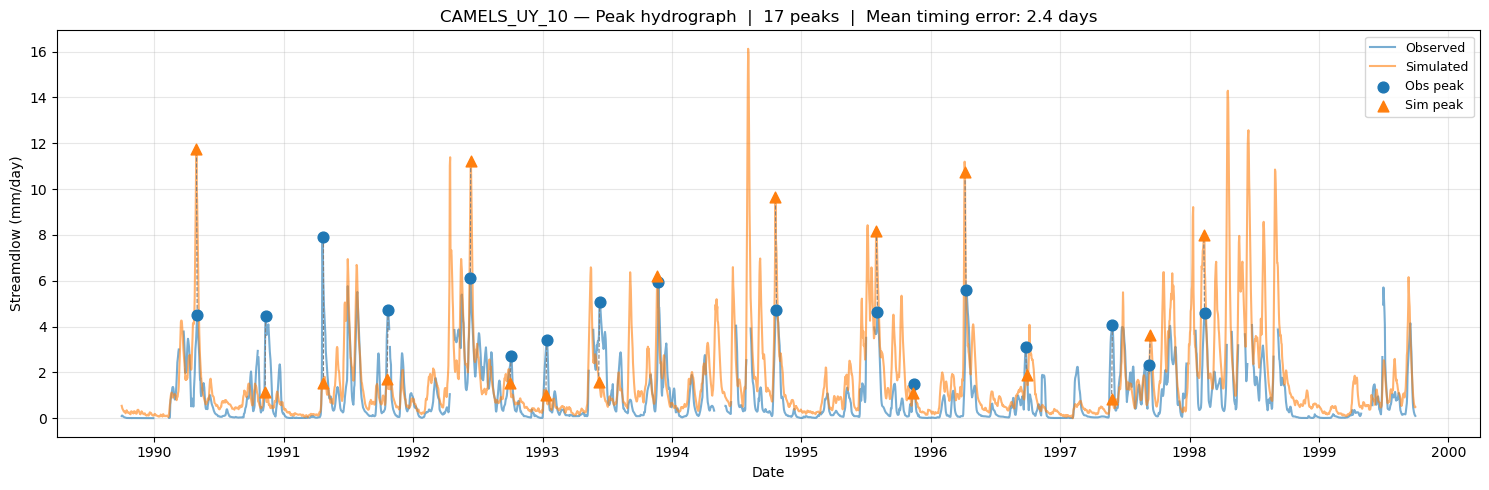

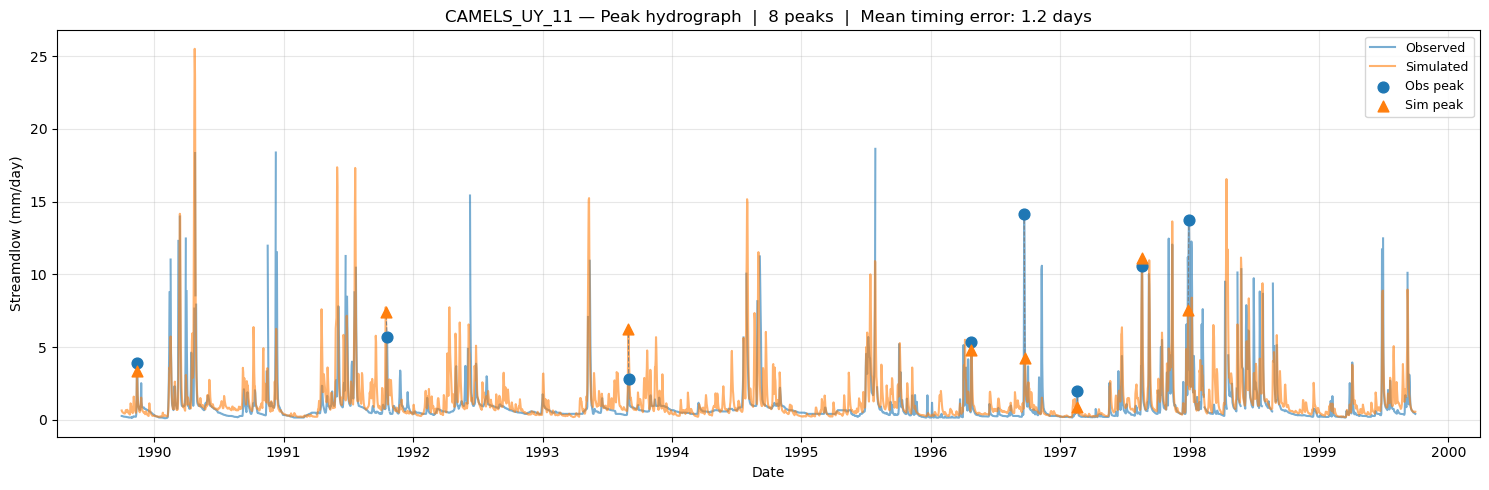

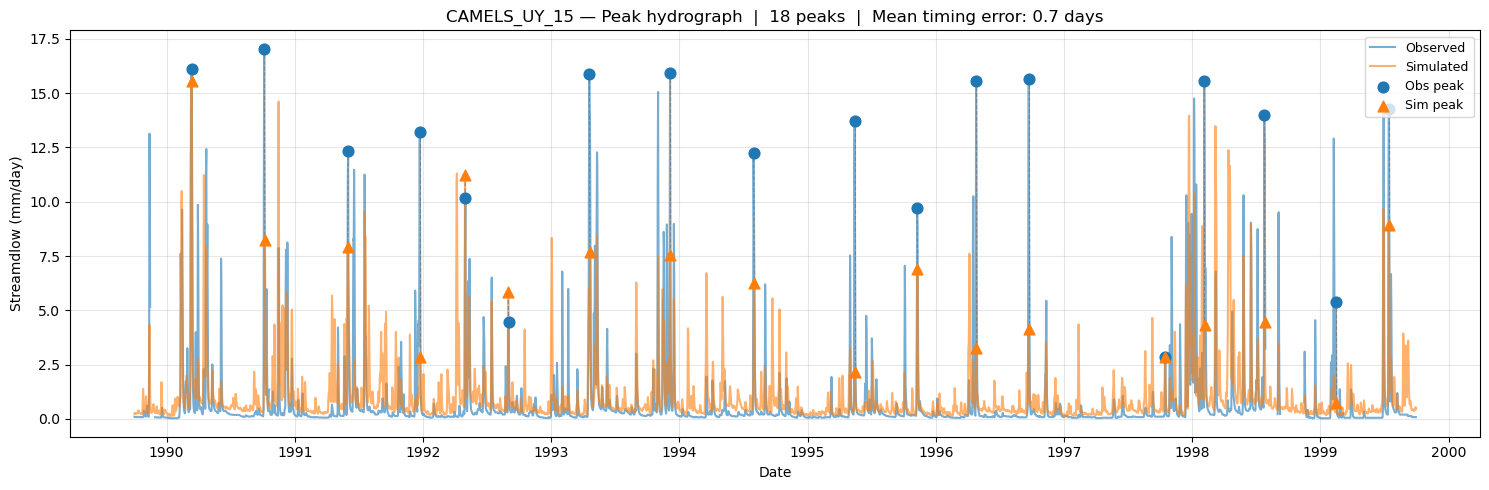

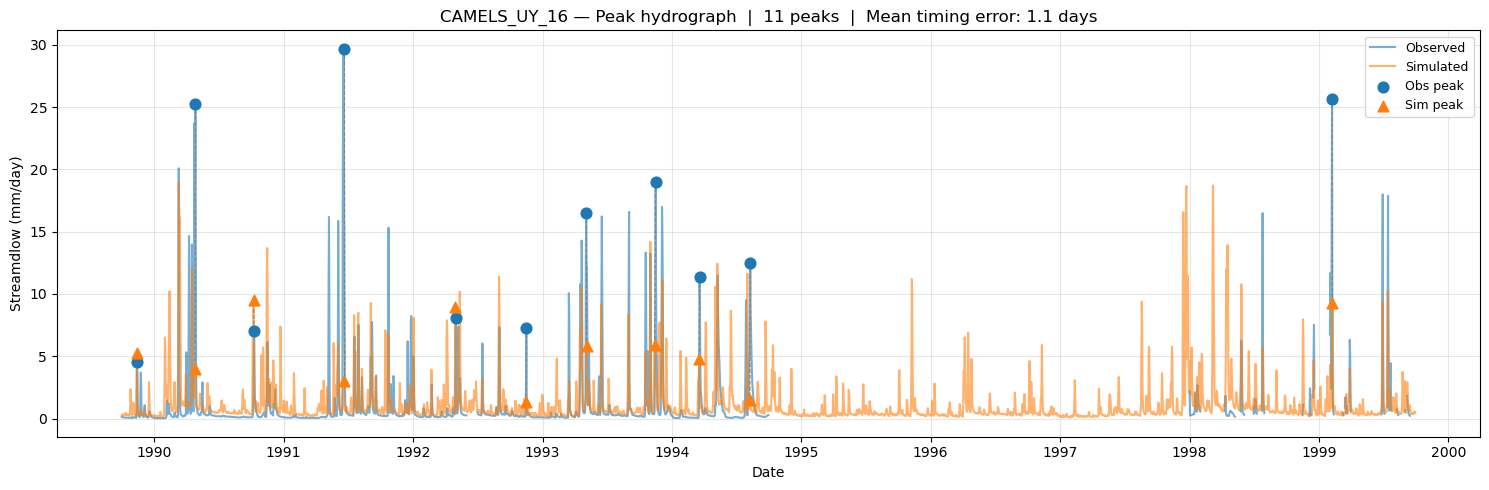

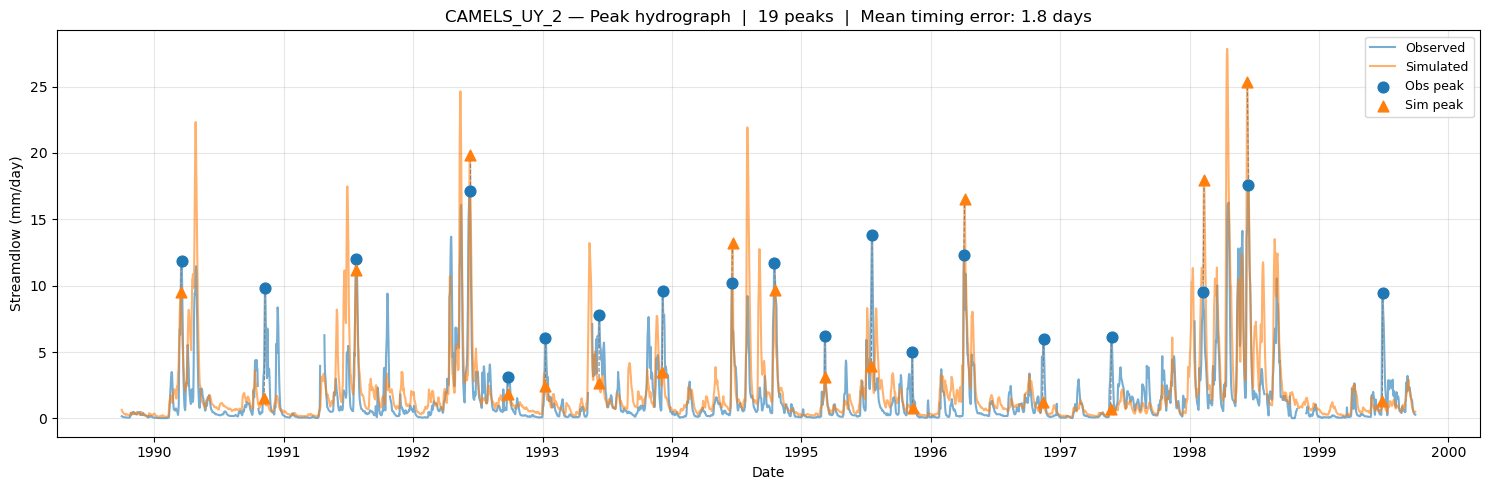

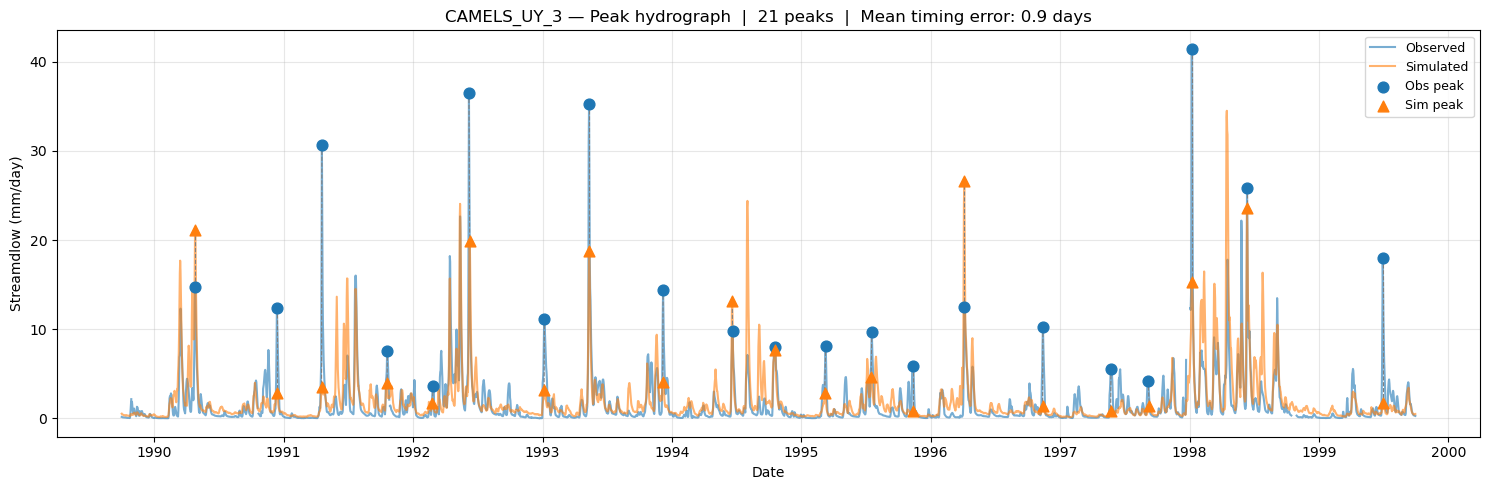

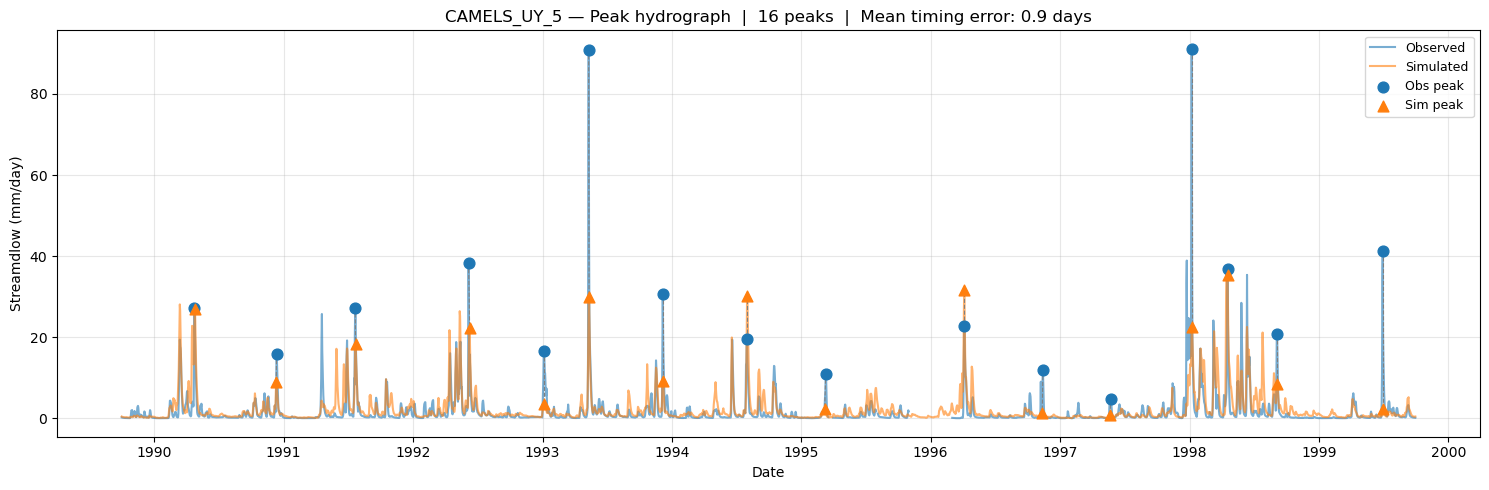

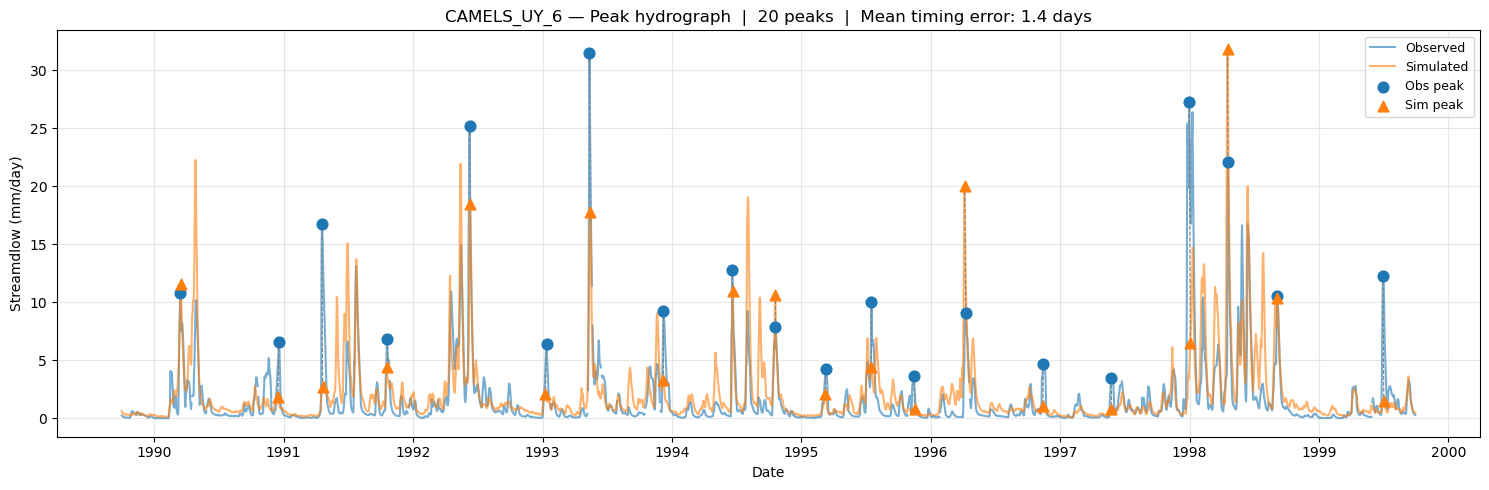

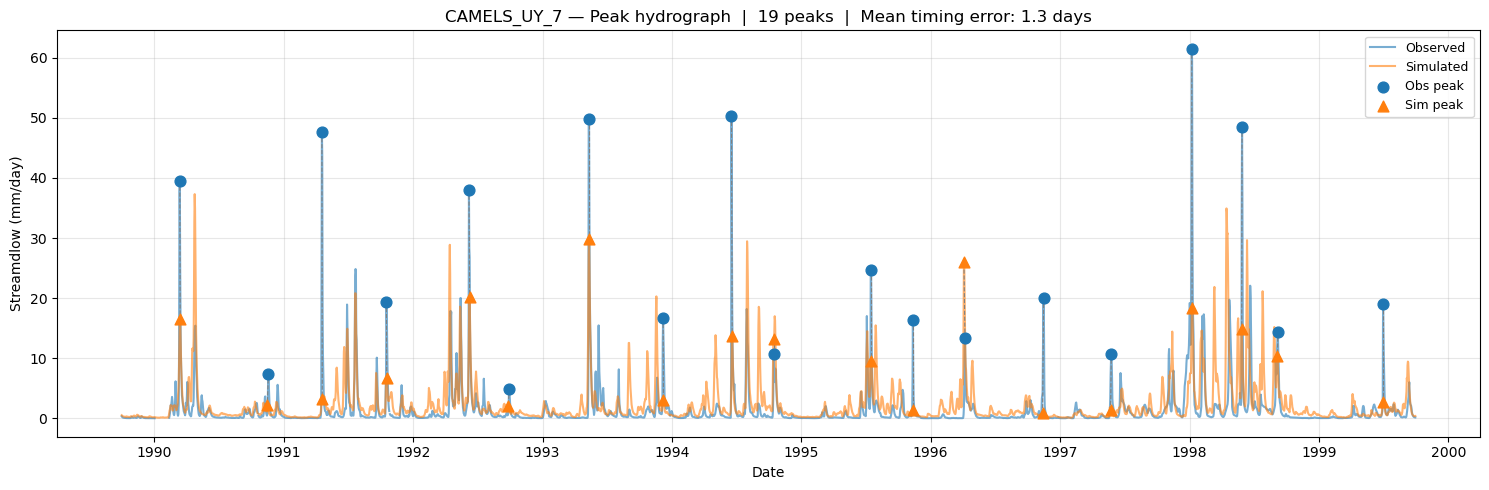

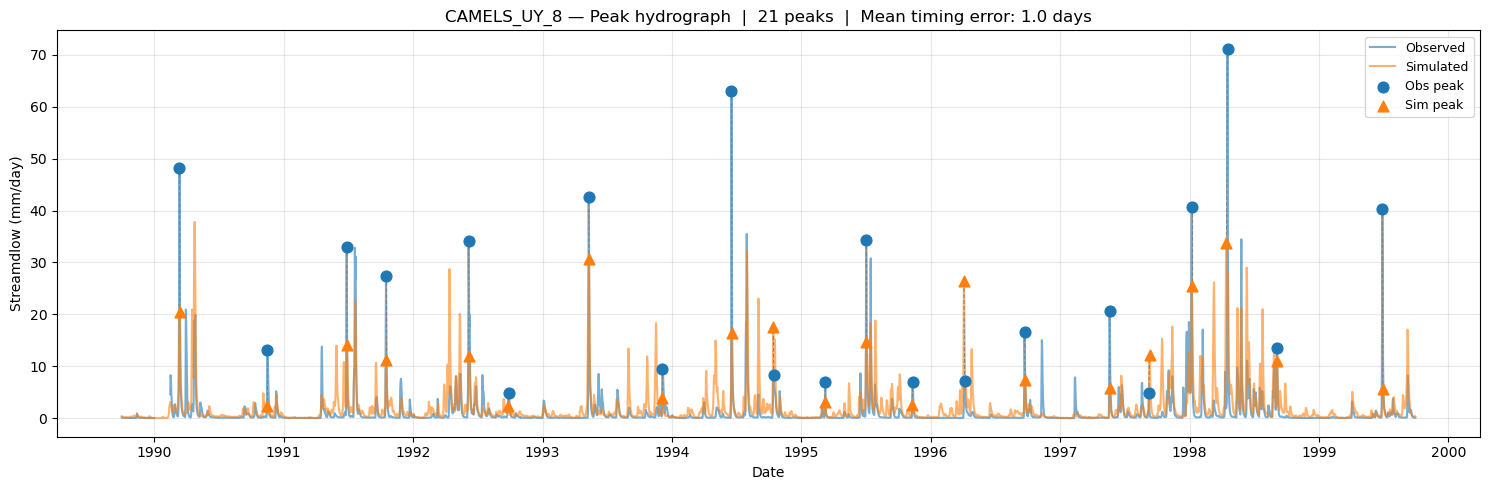

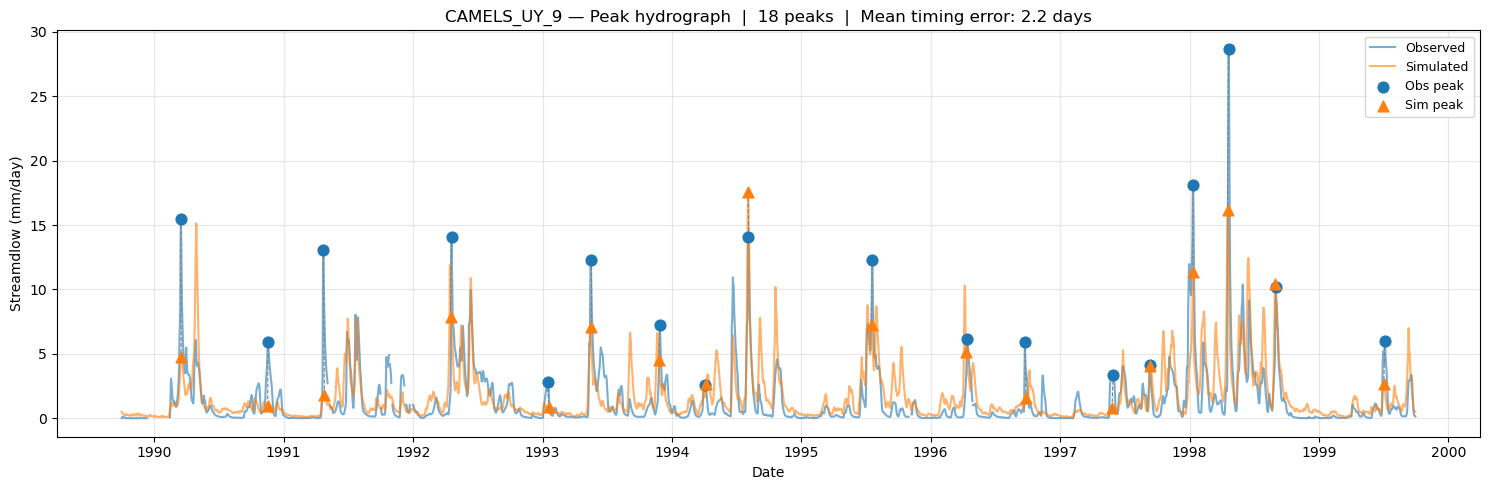

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_peak_hydrograph(basin_id, ensemble_data, window=3):
    """
    Plot full hydrograph for one basin with isolated obs/sim peak pairs highlighted.
    """
    # --- Get full time series ---
    xr_ds = ensemble_data[basin_id]['1D']['xr']
    obs_da = xr_ds['QObs_mm_d_obs'].squeeze('time_step')
    sim_da = xr_ds['QObs_mm_d_sim'].squeeze('time_step')
    dates  = pd.to_datetime(xr_ds['date'].values)

    obs_vals = obs_da.values
    sim_vals = sim_da.values

    # --- Get peaks ---
    peaks_df = extract_peaks(basin_id, ensemble_data, window=window)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(15, 5))

    ax.plot(dates, obs_vals, label='Observed', alpha=0.6)
    ax.plot(dates, sim_vals, label='Simulated', alpha=0.6)

    # Obs peaks
    ax.scatter(peaks_df['obs_date'], peaks_df['obs_flow'],
               s=60, zorder=5, label='Obs peak')

    # Sim peaks
    ax.scatter(peaks_df['sim_date'], peaks_df['sim_flow'],
               s=60, marker='^', zorder=5, label='Sim peak')

    # Connect matched pairs with a vertical line
    for _, row in peaks_df.iterrows():
        ax.plot(
            [row['obs_date'], row['sim_date']],
            [row['obs_flow'], row['sim_flow']],
            color='gray', lw=0.8, ls='--', zorder=3
        )

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlabel('Date')
    ax.set_ylabel('Streamdlow (mm/day)')
    ax.set_title(f'{basin_id} — Peak hydrograph  |  {len(peaks_df)} peaks  |  Mean timing error: {peaks_df["timing_error_days"].mean():.1f} days')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# # --- Run for one basin ---
# plot_peak_hydrograph('CAMELS_UY_11', ensemble_data)

for basin_id in ensemble_data:
    plot_peak_hydrograph(basin_id, ensemble_data)